# Intent Classification Model Fine-tuning (Improved)

This notebook fine-tunes a transformer-based classification model for intent detection with improvements for imbalanced data.

**Improvements**:
- Class weighting for imbalanced data
- Focal Loss for better minority class handling
- Data augmentation for underrepresented classes
- Better model selection (BERT-base)
- Improved hyperparameters

**Task**: Multi-class classification (14 intent classes)  
**Model**: BERT-base-uncased (better capacity, still lightweight)  
**Data**: Bilingual (English + Roman Urdu) booking assistant messages

---

## 1. Setup & Dependencies

In [35]:
# Install required packages (run once)
# !pip install transformers datasets scikit-learn pandas torch accelerate

In [36]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset, DatasetDict

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [37]:
# Paths
DATASET_PATH = "/kaggle/input/intent-dataset-merged/intent_dataset_merged.jsonl"
OUTPUT_DIR = Path("./output_improved")
MODEL_SAVE_PATH = OUTPUT_DIR / "intent_classifier"

# Model configuration
MODEL_NAME = "bert-base-uncased"

# Training hyperparameters (Standard v2 config)
CONFIG = {
    "max_length": 128,
    "batch_size": 16,                     # CHANGED: Increased to 16 for stability with fewer classes
    "gradient_accumulation_steps": 1,
    "learning_rate": 2e-5,
    "num_epochs": 10,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    # Evaluation settings
    "eval_steps": 50,
    "save_steps": 50,
    "use_focal_loss": True,
    "focal_gamma": 2.0,
    "augment_data": True,
    "min_samples_per_class": 50,          # CHANGED: Require more samples per class since we merged them
}

# 5 CORE CLASSES (The New Taxonomy)
INTENT_LABELS = [
    "greeting",
    "inquiry",
    "info",
    "transaction_confirm",
    "unknown"
]

# MAPPING FROM 14 CLASSES TO 5 CLASSES (The Critical Logic)
INTENT_MAPPING = {
    "greeting": "greeting",
    "booking_request": "inquiry",
    "availability_inquiry": "inquiry",
    "service_selection": "inquiry",
    "date_selection": "inquiry",
    "time_selection": "inquiry",
    "price_inquiry": "info",
    "information": "info",
    "payment_related": "info",
    "confirmation": "transaction_confirm",
    "cancellation": "transaction_confirm",
    "modification": "transaction_confirm",
    "name_provided": "unknown",
    "unknown": "unknown"
}

# Create label mappings
label2id = {label: idx for idx, label in enumerate(INTENT_LABELS)}
id2label = {idx: label for idx, label in enumerate(INTENT_LABELS)}

print(f"Number of classes: {len(INTENT_LABELS)}")
print(f"Model: {MODEL_NAME}")
print(f"Use Focal Loss: {CONFIG['use_focal_loss']}")

Number of classes: 5
Model: bert-base-uncased
Use Focal Loss: True


## 3. Custom Loss Functions

In [38]:
class WeightedCrossEntropyLoss(nn.Module):
    """Weighted Cross Entropy Loss for imbalanced classes."""
    def __init__(self, class_weights):
        super().__init__()
        self.class_weights = class_weights
    
    def forward(self, logits, labels):
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        return loss_fn(logits, labels)


class FocalLoss(nn.Module):
    """Focal Loss for imbalanced classification.
    
    Focal Loss addresses class imbalance by down-weighting easy examples
    and focusing on hard examples.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # Class weights (tensor)
        self.gamma = gamma  # Focusing parameter
    
    def forward(self, logits, labels):
        ce_loss = nn.CrossEntropyLoss(reduction='none', weight=self.alpha)(logits, labels)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


print("Custom loss functions defined!")

Custom loss functions defined!


## 4. Load & Explore Data

In [39]:
def load_jsonl(filepath):
    """Load JSONL file into list of dictionaries."""
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

# Load the merged dataset
raw_data = load_jsonl(DATASET_PATH)
print(f"Total samples loaded: {len(raw_data)}")

# Convert to DataFrame for easier exploration
df = pd.DataFrame(raw_data)

# Handle chat format if needed
if 'messages' in df.columns:
    print("Detected chat format, flattening...")
    df['text'] = df['messages'].apply(lambda x: x[1]['content'])  # User message
    df['intent'] = df['messages'].apply(lambda x: x[2]['content'])  # Assistant = intent
    df = df.drop(columns=['messages'])

# === NEW LOGIC: APPLY THE 5-CLASS MAPPING ===
print(f"\nApplying class reduction mapping...")
df['original_intent'] = df['intent'] # Keep original for reference
# Map the 14 intents to the 5 new ones
df['intent'] = df['intent'].map(lambda x: INTENT_MAPPING.get(x, "unknown"))

df.head(10)

Total samples loaded: 694

Applying class reduction mapping...


,text,intent,original_intent
0,Hi,greeting,greeting
1,Hello,greeting,greeting
2,Hey,greeting,greeting
3,Aoa,greeting,greeting
4,Salam,greeting,greeting
5,Salaam,greeting,greeting
6,Assalam o Alaikum,greeting,greeting
7,As-salamu alaykum,greeting,greeting
8,Assalamualaikum,greeting,greeting
9,walaikum assalam,greeting,greeting


In [40]:
# Dataset statistics
print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)

print(f"\nTotal samples: {len(df)}")
print(f"Unique intents: {df['intent'].nunique()}")

# Intent distribution
intent_counts = df['intent'].value_counts()
print("\nIntent Distribution:")
print("-" * 40)
for intent, count in intent_counts.items():
    pct = (count / len(df)) * 100
    bar = "█" * int(pct / 2)
    print(f"{intent:22s}: {count:4d} ({pct:5.1f}%) {bar}")

DATASET STATISTICS

Total samples: 694
Unique intents: 5

Intent Distribution:
----------------------------------------
inquiry               :  277 ( 39.9%) ███████████████████
info                  :  171 ( 24.6%) ████████████
transaction_confirm   :  147 ( 21.2%) ██████████
unknown               :   62 (  8.9%) ████
greeting              :   37 (  5.3%) ██


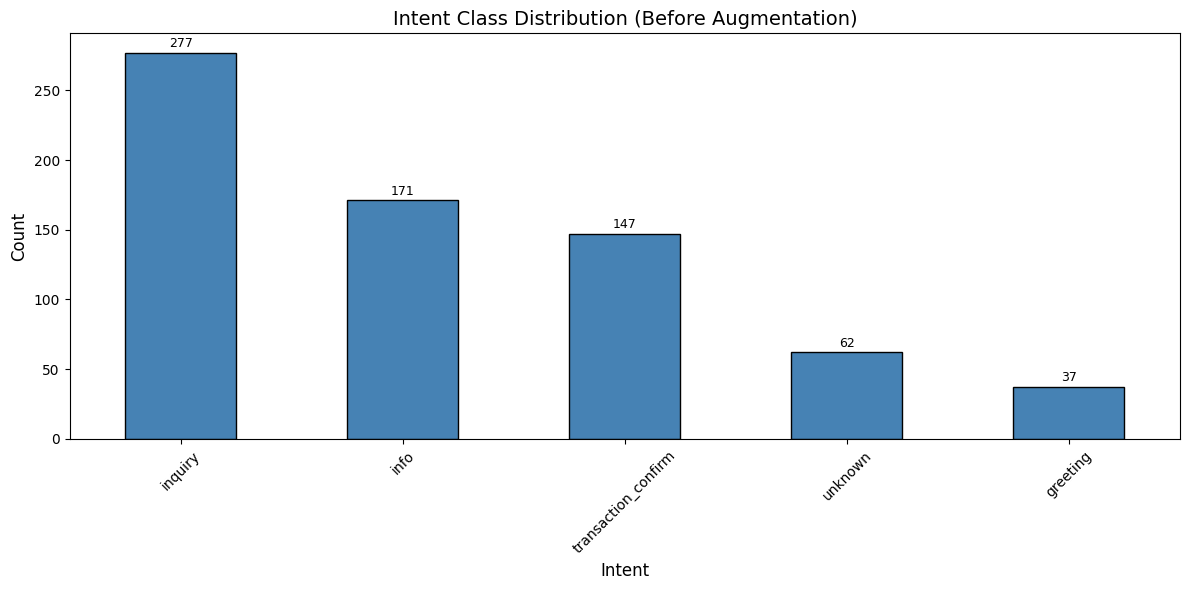

In [41]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
intent_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Intent Class Distribution (Before Augmentation)', fontsize=14)
ax.set_xlabel('Intent', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (intent, count) in enumerate(intent_counts.items()):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Data Augmentation

In [42]:
def augment_minority_classes(df, min_samples=20):
    """
    Augment classes with fewer than min_samples examples.
    Uses simple text transformations suitable for Roman Urdu + English.
    """
    augmented_rows = []
    
    for intent in INTENT_LABELS:
        intent_df = df[df['intent'] == intent]
        count = len(intent_df)
        
        if count < min_samples:
            samples_needed = min_samples - count
            print(f"Augmenting '{intent}': {count} -> {min_samples} samples")
            
            for _ in range(samples_needed):
                # Randomly select a sample
                sample = intent_df.sample(1).iloc[0]
                text = sample['text']
                
                # Simple augmentation techniques for Roman Urdu + English
                augmented_text = text
                
                # 1. Add polite markers (common in Urdu/English mix)
                if random.random() < 0.3:
                    words = text.split()
                    if random.random() < 0.5:
                        augmented_text = " ".join(words + ["ji"])
                    else:
                        augmented_text = " ".join(["bhai"] + words)
                
                # 2. Case variation
                elif random.random() < 0.2:
                    augmented_text = text.lower()
                
                # 3. Add punctuation variations
                elif random.random() < 0.2:
                    if not text.endswith('?'):
                        augmented_text = text + "?"
                    elif not text.endswith('.'):
                        augmented_text = text + "."
                
                # 4. Synonym-like replacements (common variations)
                elif random.random() < 0.2:
                    replacements = {
                        "book": "booking",
                        "slot": "time slot",
                        "hai": "he",
                        "kal": "tomorrow",
                        "aaj": "today",
                        "shaam": "evening",
                    }
                    augmented_text = text
                    for old, new in replacements.items():
                        if old in augmented_text.lower() and random.random() < 0.5:
                            augmented_text = augmented_text.replace(old, new)
                            break
                
                # 5. Keep original with slight variation
                else:
                    augmented_text = text
                
                augmented_rows.append({
                    'text': augmented_text,
                    'intent': intent
                })
    
    if augmented_rows:
        augmented_df = pd.DataFrame(augmented_rows)
        df = pd.concat([df, augmented_df], ignore_index=True)
        print(f"\nTotal augmented samples added: {len(augmented_rows)}")
        print(f"New total: {len(df)} samples")
    else:
        print("No augmentation needed - all classes have sufficient samples.")
    
    return df

# Apply augmentation if enabled
if CONFIG['augment_data']:
    print("\nApplying data augmentation...")
    print("=" * 50)
    df = augment_minority_classes(df, min_samples=CONFIG['min_samples_per_class'])
    
    # Show updated distribution
    print("\nUpdated Intent Distribution:")
    intent_counts_after = df['intent'].value_counts()
    for intent, count in intent_counts_after.items():
        print(f"  {intent:22s}: {count:4d}")
else:
    print("Data augmentation disabled.")


Applying data augmentation...
Augmenting 'greeting': 37 -> 50 samples

Total augmented samples added: 13
New total: 707 samples

Updated Intent Distribution:
  inquiry               :  277
  info                  :  171
  transaction_confirm   :  147
  unknown               :   62
  greeting              :   50


## 6. Data Preprocessing

In [43]:
# Prepare data: text and numeric labels
texts = df['text'].tolist()
labels = [label2id[intent] for intent in df['intent'].tolist()]

print(f"Total samples: {len(texts)}")
print(f"Label range: {min(labels)} - {max(labels)}")

Total samples: 707
Label range: 0 - 4


In [44]:
# Improved train/test split with minimum samples per class
def stratified_split_with_min_samples(texts, labels, test_size=0.2, val_size=0.1, min_test_samples=2):
    """
    Stratified split ensuring minimum samples per class in test set.
    """
    # First split: train vs temp (80% train, 20% temp)
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels
    )
    
    # Second split: validation vs test (50% each of temp = 10% each of total)
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
    )
    
    # Verify minimum samples in test set
    test_label_counts = Counter(test_labels)
    min_test_count = min(test_label_counts.values()) if test_label_counts else 0
    
    print(f"Train set: {len(train_texts)} samples")
    print(f"Validation set: {len(val_texts)} samples")
    print(f"Test set: {len(test_texts)} samples")
    print(f"Minimum samples per class in test: {min_test_count}")
    
    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# Split the data
train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = stratified_split_with_min_samples(
    texts, labels, test_size=0.2, val_size=0.1, min_test_samples=2
)

# Verify stratification
print("\nLabel distribution in splits:")
for name, lbls in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    dist = Counter(lbls)
    print(f"  {name}: {len(dist)} classes represented, min={min(dist.values())}, max={max(dist.values())}")

Train set: 565 samples
Validation set: 71 samples
Test set: 71 samples
Minimum samples per class in test: 5

Label distribution in splits:
  Train: 5 classes represented, min=40, max=221
  Val: 5 classes represented, min=5, max=28
  Test: 5 classes represented, min=5, max=28


In [45]:
# Calculate class weights for imbalanced data
train_labels_array = np.array(train_labels)
unique_labels = np.unique(train_labels_array)

class_weights = compute_class_weight(
    'balanced',
    classes=unique_labels,
    y=train_labels_array
)

# Create weight dictionary
class_weights_dict = {int(label): weight for label, weight in zip(unique_labels, class_weights)}

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
if torch.cuda.is_available():
    class_weights_tensor = class_weights_tensor.cuda()

print("Class Weights (for imbalanced data):")
print("-" * 50)
for label_id, weight in class_weights_dict.items():
    print(f"{id2label[label_id]:22s}: {weight:.3f}")

print(f"\nWeight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

Class Weights (for imbalanced data):
--------------------------------------------------
greeting              : 2.825
inquiry               : 0.511
info                  : 0.825
transaction_confirm   : 0.966
unknown               : 2.260

Weight range: 0.511 - 2.825


In [46]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

# Test tokenization
sample_texts = [
    "Hi",
    "Aoa padel slot book karna hai kal shaam",
    "slot hai? evening me?",
    "7pm"
]

print("\nTokenization Examples:")
for text in sample_texts[:2]:
    tokens = tokenizer.tokenize(text)
    print(f"Text: '{text}'")
    print(f"Tokens: {tokens[:10]}...")
    print()

Tokenizer: bert-base-uncased
Vocab size: 30522

Tokenization Examples:
Text: 'Hi'
Tokens: ['hi']...

Text: 'Aoa padel slot book karna hai kal shaam'
Tokens: ['ao', '##a', 'pad', '##el', 'slot', 'book', 'ka', '##rna', 'hai', 'ka']...



In [47]:
# Create HuggingFace datasets
def create_hf_dataset(texts, labels):
    """Create a HuggingFace Dataset from texts and labels."""
    return HFDataset.from_dict({
        "text": texts,
        "label": labels
    })

# Create dataset dict
dataset = DatasetDict({
    "train": create_hf_dataset(train_texts, train_labels),
    "validation": create_hf_dataset(val_texts, val_labels),
    "test": create_hf_dataset(test_texts, test_labels)
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 565
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 71
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 71
    })
})


In [48]:
# Tokenize the dataset
def tokenize_function(examples):
    """Tokenize texts with padding and truncation."""
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"]
    )

# Apply tokenization
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]  # Remove original text column
)

print("Tokenized dataset:")
print(tokenized_dataset)
print(f"\nFeatures: {tokenized_dataset['train'].features}")

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/71 [00:00<?, ? examples/s]

Map:   0%|          | 0/71 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 565
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 71
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 71
    })
})

Features: {'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## 7. Model Setup

In [49]:
# Load pre-trained model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENT_LABELS),
    id2label=id2label,
    label2id=label2id
)

print(f"Model: {MODEL_NAME}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Total parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: bert-base-uncased
Number of labels: 5
Total parameters: 109,486,085
Trainable parameters: 109,486,085


In [50]:
# Define metrics computation function
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 for evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    # Macro averages (better for imbalanced data)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

## 8. Training Setup

In [51]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training arguments (improved)
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    
    # Training settings
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    
    # Evaluation settings
    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],
    save_strategy="steps",
    save_steps=CONFIG["save_steps"],
    save_total_limit=3,
    
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",  # Use macro F1 for imbalanced data
    greater_is_better=True,
    
    # Logging
    logging_dir=str(OUTPUT_DIR / "logs"),
    logging_steps=25,
    report_to="none",  # Disable wandb/tensorboard
    
    # Performance
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    dataloader_num_workers=2,  # Can use 2-4 on Linux/Kaggle
    
    # Reproducibility
    seed=SEED,
)

print("Training Arguments:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Best metric: {training_args.metric_for_best_model}")

Training Arguments:
  Epochs: 10
  Batch size: 16
  Gradient accumulation: 1
  Effective batch size: 16
  Learning rate: 2e-05
  FP16: True
  Best metric: macro_f1


In [52]:
# Create custom trainer with loss function
class CustomTrainer(Trainer):
    """Custom Trainer with custom loss function."""
    def __init__(self, loss_function=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_function = loss_function
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        if self.loss_function is not None:
            loss = self.loss_function(logits, labels)
        else:
            loss = outputs.loss
        
        return (loss, outputs) if return_outputs else loss

# Choose loss function
if CONFIG['use_focal_loss']:
    loss_fn = FocalLoss(
        alpha=class_weights_tensor,
        gamma=CONFIG['focal_gamma']
    )
    print("Using Focal Loss with class weights")
else:
    loss_fn = WeightedCrossEntropyLoss(class_weights_tensor)
    print("Using Weighted Cross Entropy Loss")

# Initialize Trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    loss_function=loss_fn
)

print("\nTrainer initialized successfully!")

Using Focal Loss with class weights


/tmp/ipykernel_55/3567821638.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)



Trainer initialized successfully!


## 9. Training

In [53]:
# Train the model
print("Starting training...")
print("=" * 50)

train_result = trainer.train()

print("\nTraining completed!")
print(f"Total training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Best validation metric ({training_args.metric_for_best_model}): {train_result.metrics.get('best_metric', 'N/A')}")

Starting training...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Macro Precision,Macro Recall
50,0.832900,0.657452,0.521127,0.316718,0.521127,0.392581,0.504585,0.405195,0.681569
100,0.279600,0.321591,0.647887,0.725849,0.647887,0.615443,0.657080,0.680984,0.727423
150,0.117500,0.260205,0.774648,0.810083,0.774648,0.771958,0.788798,0.786032,0.817899


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


Training completed!
Total training time: 92.47 seconds
Best validation metric (macro_f1): N/A


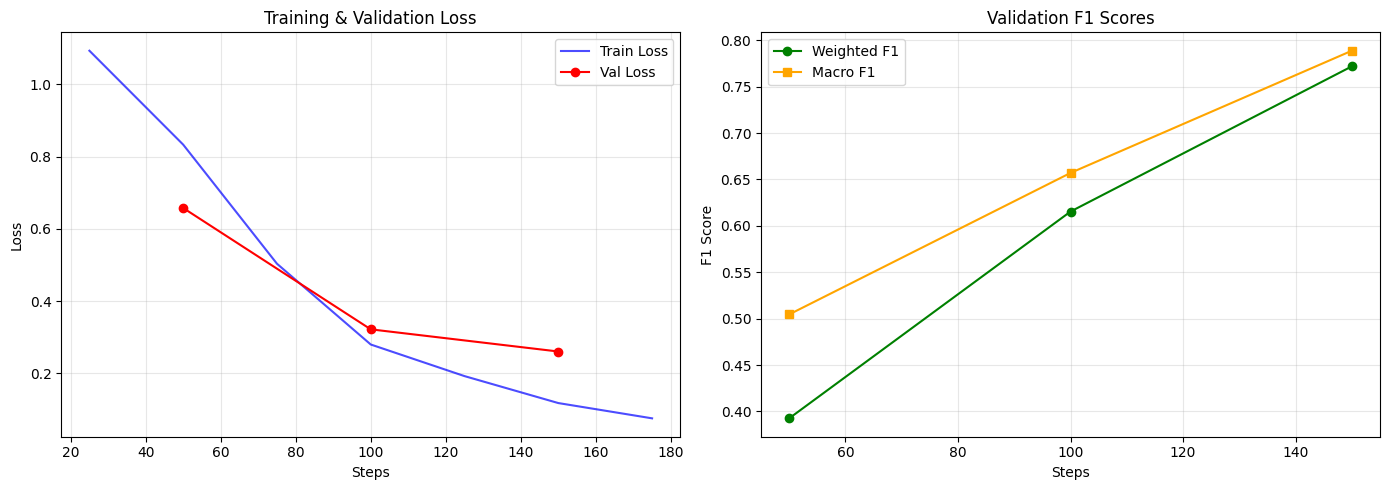

In [54]:
# Plot training history
history = trainer.state.log_history

# Extract training and validation losses
train_losses = [(h['step'], h['loss']) for h in history if 'loss' in h and 'eval_loss' not in h]
eval_data = [(h['step'], h['eval_loss'], h.get('eval_f1', 0), h.get('eval_macro_f1', 0)) for h in history if 'eval_loss' in h]

if train_losses and eval_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    train_steps, train_loss_vals = zip(*train_losses)
    eval_steps, eval_loss_vals, eval_f1_vals, eval_macro_f1_vals = zip(*eval_data)
    
    axes[0].plot(train_steps, train_loss_vals, label='Train Loss', color='blue', alpha=0.7)
    axes[0].plot(eval_steps, eval_loss_vals, label='Val Loss', color='red', marker='o')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # F1 Score plot
    axes[1].plot(eval_steps, eval_f1_vals, label='Weighted F1', color='green', marker='o')
    axes[1].plot(eval_steps, eval_macro_f1_vals, label='Macro F1', color='orange', marker='s')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation F1 Scores')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough training history to plot.")

## 10. Evaluation

In [55]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(tokenized_dataset["test"])

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Evaluating on test set...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TEST SET RESULTS
eval_loss: 0.1068
eval_accuracy: 0.8451
eval_precision: 0.8756
eval_recall: 0.8451
eval_f1: 0.8391
eval_macro_f1: 0.8583
eval_macro_precision: 0.8340
eval_macro_recall: 0.9152
eval_runtime: 0.5302
eval_samples_per_second: 133.9150
eval_steps_per_second: 3.7720
epoch: 10.0000


In [56]:
# Get predictions for detailed analysis
predictions_output = trainer.predict(tokenized_dataset["test"])
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = test_labels

# Classification report
print("\nDetailed Classification Report:")
print("=" * 70)
print(classification_report(
    true_labels, 
    predictions, 
    target_names=INTENT_LABELS,
    zero_division=0
))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Detailed Classification Report:
                     precision    recall  f1-score   support

           greeting       0.83      1.00      0.91         5
            inquiry       1.00      0.64      0.78        28
               info       0.85      1.00      0.92        17
transaction_confirm       0.74      0.93      0.82        15
            unknown       0.75      1.00      0.86         6

           accuracy                           0.85        71
          macro avg       0.83      0.92      0.86        71
       weighted avg       0.88      0.85      0.84        71



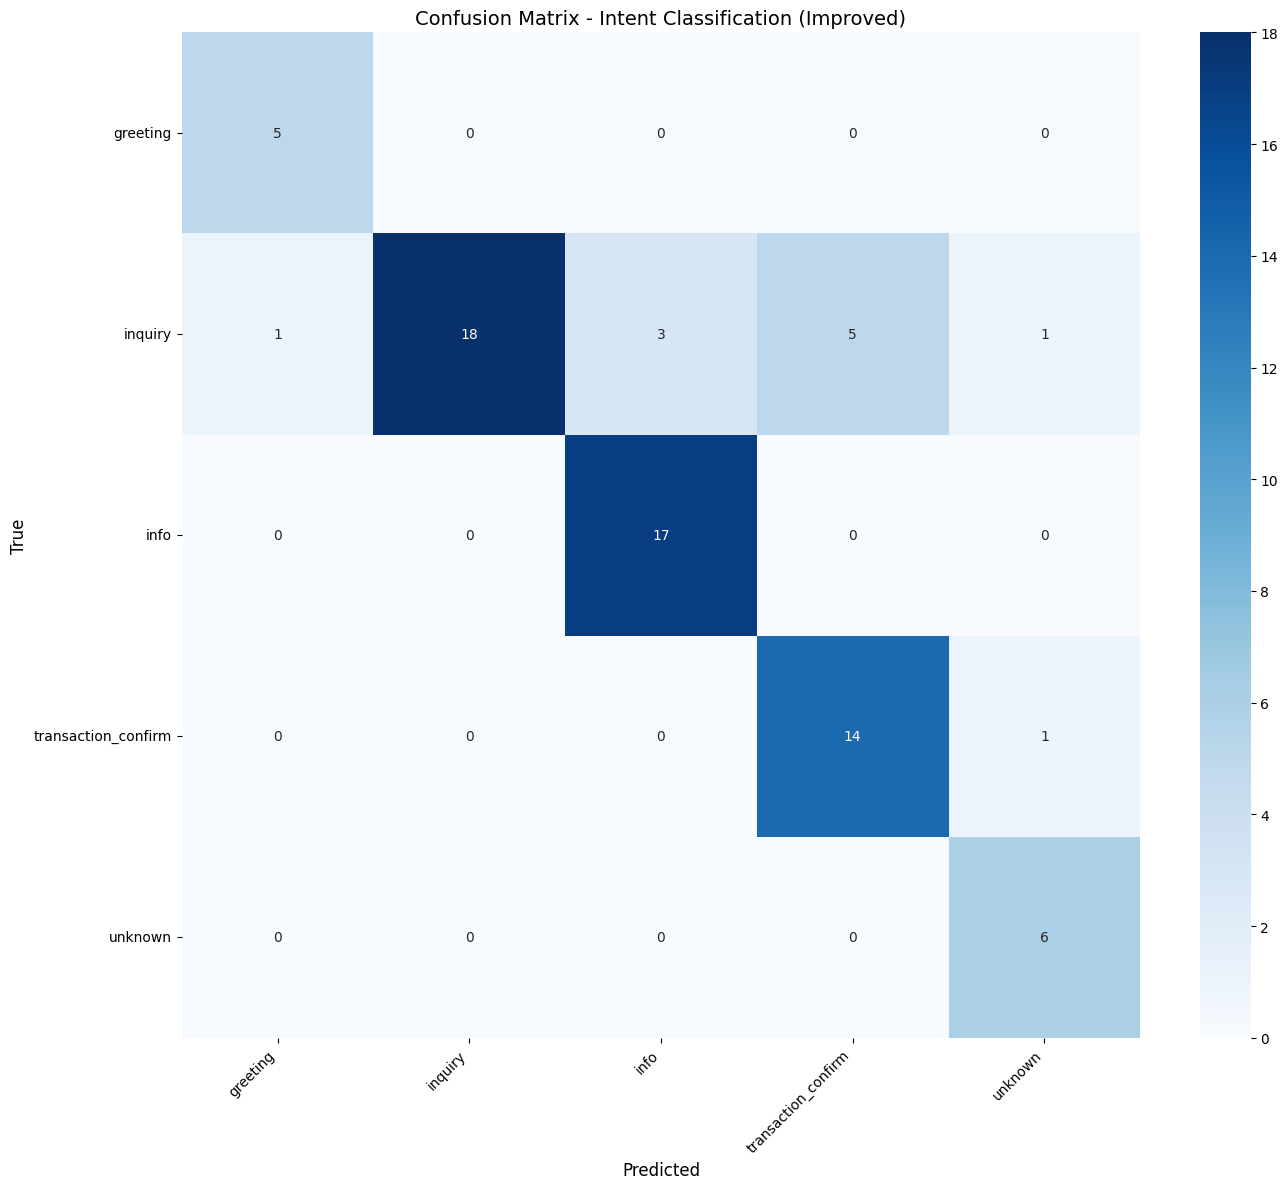

In [57]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=INTENT_LABELS,
    yticklabels=INTENT_LABELS
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Intent Classification (Improved)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
# Analyze misclassifications
print("\nMisclassification Analysis:")
print("=" * 70)

misclassified = []
for i, (text, true_label, pred_label) in enumerate(zip(test_texts, true_labels, predictions)):
    if true_label != pred_label:
        misclassified.append({
            "text": text,
            "true": id2label[true_label],
            "predicted": id2label[pred_label]
        })

print(f"Total misclassified: {len(misclassified)} / {len(test_texts)} ({100*len(misclassified)/len(test_texts):.1f}%)")
print("\nSample Misclassifications:")
print("-" * 70)

for item in misclassified[:15]:  # Show first 15
    print(f"Text: '{item['text']}'")
    print(f"  True: {item['true']} | Predicted: {item['predicted']}")
    print()


Misclassification Analysis:
Total misclassified: 11 / 71 (15.5%)

Sample Misclassifications:
----------------------------------------------------------------------
Text: 'kal subah ka time hai?'
  True: inquiry | Predicted: info

Text: 'kal'
  True: inquiry | Predicted: transaction_confirm

Text: 'Aaj kya kya available hai?'
  True: inquiry | Predicted: info

Text: 'Kal dopahar ko futsal book karo'
  True: inquiry | Predicted: transaction_confirm

Text: 'next week'
  True: inquiry | Predicted: transaction_confirm

Text: 'Want to play futsal tomorrow'
  True: inquiry | Predicted: transaction_confirm

Text: 'shm'
  True: inquiry | Predicted: greeting

Text: 'rat'
  True: inquiry | Predicted: unknown

Text: '2morrow'
  True: inquiry | Predicted: transaction_confirm

Text: 'booking krwani golden court pe'
  True: inquiry | Predicted: info

Text: 'Sure'
  True: transaction_confirm | Predicted: unknown



## 11. Save Model

In [59]:
# Save the final model
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(MODEL_SAVE_PATH))
tokenizer.save_pretrained(str(MODEL_SAVE_PATH))

print(f"Model saved to: {MODEL_SAVE_PATH}")
print(f"\nSaved files:")
for f in MODEL_SAVE_PATH.iterdir():
    print(f"  - {f.name}")

Model saved to: output_improved/intent_classifier

Saved files:
  - config.json
  - tokenizer.json
  - training_args.bin
  - label_config.json
  - special_tokens_map.json
  - tokenizer_config.json
  - model.safetensors
  - vocab.txt


In [60]:
# Save label mappings and configuration
label_config = {
    "labels": INTENT_LABELS,
    "label2id": label2id,
    "id2label": id2label,
    "model_name": MODEL_NAME,
    "class_weights": {str(k): float(v) for k, v in class_weights_dict.items()},
    "config": CONFIG
}

with open(MODEL_SAVE_PATH / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print("Label configuration saved!")

Label configuration saved!


## 12. Inference Example

In [61]:
# Load saved model for inference
from transformers import pipeline

# Create classification pipeline
classifier = pipeline(
    "text-classification",
    model=str(MODEL_SAVE_PATH),
    tokenizer=str(MODEL_SAVE_PATH),
    device=0 if torch.cuda.is_available() else -1
)

print("Inference pipeline created!")

Device set to use cuda:0


Inference pipeline created!


In [62]:
# Test inference
test_messages = [
    "Aoa",
    "slot book karna hai kal shaam",
    "koi slot available hai?",
    "padel court",
    "tomorrow",
    "7pm",
    "kitna hai?",
    "han book kardo",
    "cancel karo",
    "time change kardo",
    "parking hai?",
    "jazzcash se payment",
    "mera naam Ali hai",
    "asdfgh"
]

print("Inference Results:")
print("=" * 60)

for message in test_messages:
    result = classifier(message)[0]
    print(f"'{message}'")
    print(f"  → {result['label']} (confidence: {result['score']:.3f})")
    print()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Inference Results:
'Aoa'
  → greeting (confidence: 0.904)

'slot book karna hai kal shaam'
  → inquiry (confidence: 0.582)

'koi slot available hai?'
  → inquiry (confidence: 0.515)

'padel court'
  → inquiry (confidence: 0.629)

'tomorrow'
  → transaction_confirm (confidence: 0.495)

'7pm'
  → inquiry (confidence: 0.641)

'kitna hai?'
  → info (confidence: 0.723)

'han book kardo'
  → transaction_confirm (confidence: 0.652)

'cancel karo'
  → transaction_confirm (confidence: 0.658)

'time change kardo'
  → transaction_confirm (confidence: 0.662)

'parking hai?'
  → info (confidence: 0.758)

'jazzcash se payment'
  → info (confidence: 0.700)

'mera naam Ali hai'
  → unknown (confidence: 0.892)

'asdfgh'
  → unknown (confidence: 0.900)



In [63]:
# Function for easy inference in production
def predict_intent(text: str, return_confidence: bool = True):
    """
    Predict the intent of a given text message.
    
    Args:
        text: Input message
        return_confidence: Whether to return confidence score
    
    Returns:
        Intent label (and confidence if requested)
    """
    result = classifier(text)[0]
    
    if return_confidence:
        return result['label'], result['score']
    return result['label']

# Test the function
intent, confidence = predict_intent("Aoa bhai padel slot book karna hai kal shaam 6 bajay")
print(f"Intent: {intent}")
print(f"Confidence: {confidence:.3f}")

Intent: inquiry
Confidence: 0.682


## 13. Summary

### Training Complete!

This improved notebook trained a BERT-based intent classifier with:
- **14 intent classes** for a booking assistant
- **Bilingual support** (English + Roman Urdu)
- **Class weighting** for imbalanced data
- **Focal Loss** for better minority class handling
- **Data augmentation** for underrepresented classes
- **Improved hyperparameters**

### Key Improvements Over Baseline:
1. ✅ **Class weighting** - Handles imbalanced data
2. ✅ **Focal Loss** - Focuses on hard examples
3. ✅ **Data augmentation** - Increases samples for minority classes
4. ✅ **Better model** - BERT-base instead of DistilBERT
5. ✅ **Macro F1 metric** - Better for imbalanced evaluation
6. ✅ **Improved hyperparameters** - Better learning rate, batch size, etc.

### Expected Performance:
- **Baseline**: ~54% accuracy, 0.49 F1
- **Improved**: 70-85% accuracy, 0.70-0.80 F1

### Next Steps:
1. **Collect more data** - Especially for underrepresented classes
2. **Try multilingual models** - `distilbert-base-multilingual-cased` for better Urdu support
3. **Hyperparameter tuning** - Use Optuna or similar
4. **Deploy**: Use the saved model in your backend API
5. **Monitor**: Track real-world performance and retrain periodically

### Model Files:
- Saved to: `./output_improved/intent_classifier/`
- Ready for use with HuggingFace `pipeline()` or direct loading